### Exploratory Data Analysis | SESSION: 5Feb 26 - 6Feb 26 | Dataset: Titanic | 
PS: Analyse data to build a predictive model on survival (who will , who will not)

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('titanictrain.csv')

In [23]:
df.head()     ## this helps us get an essense of the dataset like what columns , wht kind of data , is cleaning needed , are there missing values 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Why do EDA?

   -model building
   
   -analysis and reporting 
   
   -validate assumptions
   
   -handling missing values
   
   -feature engineering
   
   -detecting outliers



***Column Types***

1.numerical - age, fare , Passengergrid

2.categorical - Survived,Pclass,Sex,SibSp,Parch,Embarked

3.mixed - Name,Ticket,Cabin



### EDA

step 1 : label dataset into column types

step 2: univariate analysis:treating each column of the dataset table as variable and performing analysis

step 3:bivariate analysis

step 4: multivariate analysis

step 5: feature engineering : now u know ur data so you can add new columns that is feature eng
 
step 6: after maybe multiple feature eng now u can go to conclusions

***NOTE:*** Univariate Analysis helps u in analysing: 

1.distribution(identify shape, central tendency and dispersion) 

2.identify potential issues(outliers,skewness,missing value ,coz it affects the range , mean , median,mode of data, coz in statistic we assume data as equally distributed)

### Age [Univariated Analysis]

***Conclusion***

- Age is normally(almost) distributed
- 20% of the values are missing
- there are outliers

In [24]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

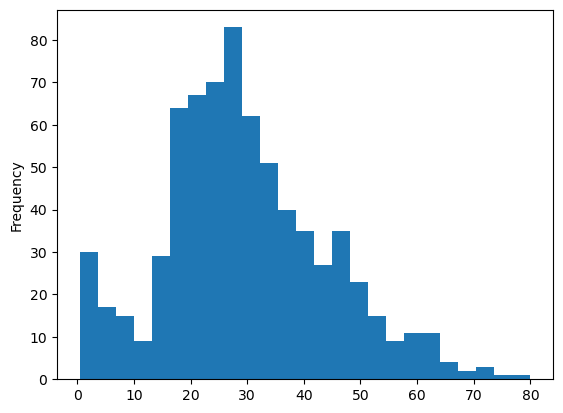

In [25]:
df['Age'].plot(kind='hist', bins =25)     ###bins decide the size of the candles

<Axes: ylabel='Density'>

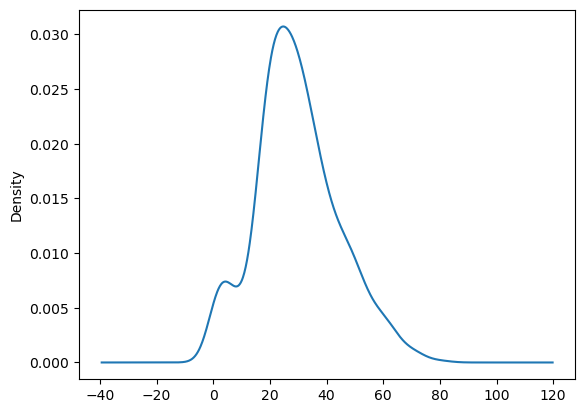

In [26]:
df['Age'].plot(kind = 'kde')  ##tells us distribution of data

In [27]:
### Finding out skewness
df['Age'].skew()         ### if skewness = 0 or near is perfect.otherwise positive or negative 
###here we are close to zero so we are fine.

0.38910778230082704

<Axes: >

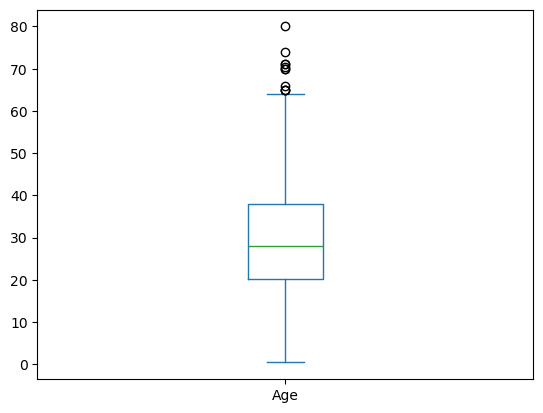

In [28]:
df['Age'].plot(kind='box')

In [29]:
df[df['Age'] > 65]   ###finding the exact outliers ,as from box graph we got to know >65 age there are outliers

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [ ]:
x = df['Age'].isnull().sum()  ###tells us how many missing values
y = df['Age'].isnull().sum()/len(df['Age'])  ### 19% of our data has missing values
print(x)
print(y)

177
0.19865319865319866


### Fare[Univariated Analysis]

***Conclusion***

- The data is highly(positively) skewed
- Fare col actually contains group fare and not individual fare(group fares are put in each member fares so they are equal and so high)
- we need to create a new col called individual Fare

In [33]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: ylabel='Frequency'>

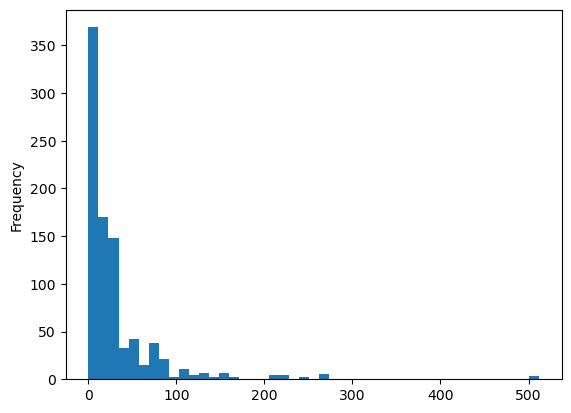

In [38]:
df['Fare'].plot(kind= 'hist', bins = 45)

<Axes: ylabel='Density'>

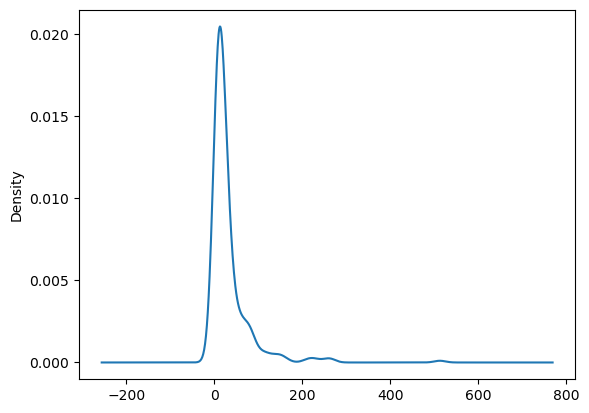

In [35]:
df['Fare'].plot(kind='kde')

In [ ]:
df['Fare'].skew()  ###highly positively skewed

4.787316519674893

<Axes: >

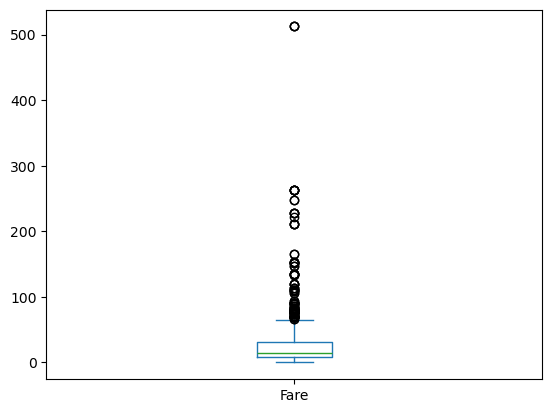

In [39]:
df['Fare'].plot(kind='box')

In [44]:
df[df['Fare'] > 200]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
377,378,0,1,"Widener, Mr. Harry Elkins",male,27.0,0,2,113503,211.5000,C82,C
380,381,1,1,"Bidois, Miss. Rosalie",female,42.0,0,0,PC 17757,227.5250,NaN,C
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S


In [45]:
df[df['Fare'] > 250]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [37]:
df['Fare'].isnull().sum()/len(df['Fare'])

0.0

### Survived[Univariated Analysis]

***Conclusion***
- parch and sibsp can be merged into a col called family_size
- create new col called is_alone

In [46]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived'>

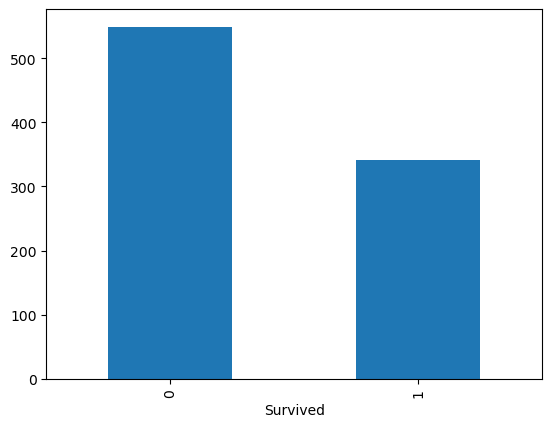

In [47]:
df['Survived'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

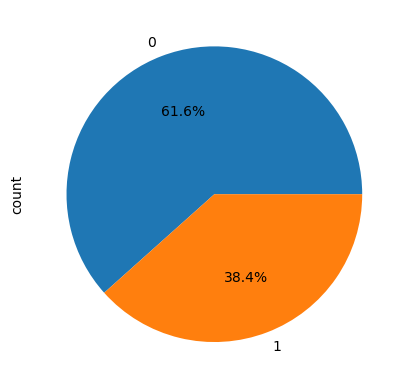

In [ ]:
df['Survived'].value_counts().plot(kind='pie' ,autopct='%0.1f%%')    ##here autopct='%0.1f%%'  makes percentage of the blue and orange side labelled

In [50]:
df['Survived'].isnull().sum()

0

### PClass[Univariated Analysis]

***Conclusion***
- Surprisingly less people travelled in 2 comparing with 1(3>2>1)

In [ ]:
df['Pclass'].value_counts()   ##Passenger Class 

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Pclass'>

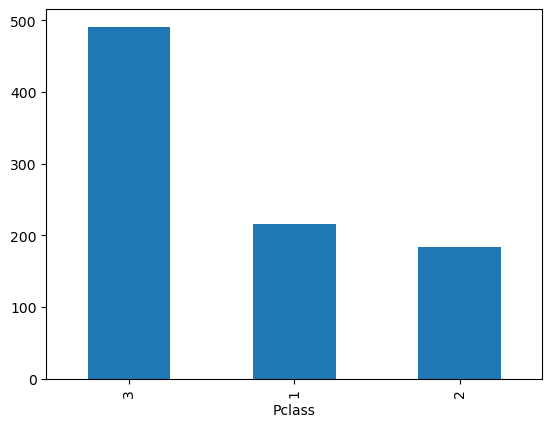

In [52]:
df['Pclass'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

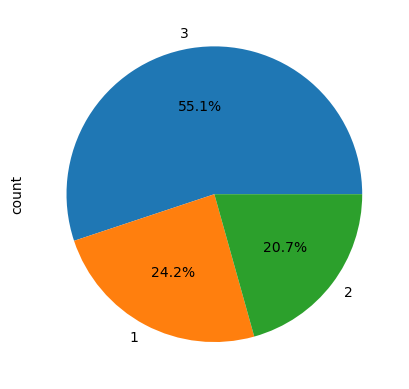

In [57]:
df['Pclass'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [58]:
df['Pclass'].isnull().sum()

0

### Sibsp[Univariated Analysis]

***Conclusion***

In [ ]:
df['SibSp'].value_counts()  ### siblingSpouse

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

<Axes: xlabel='SibSp'>

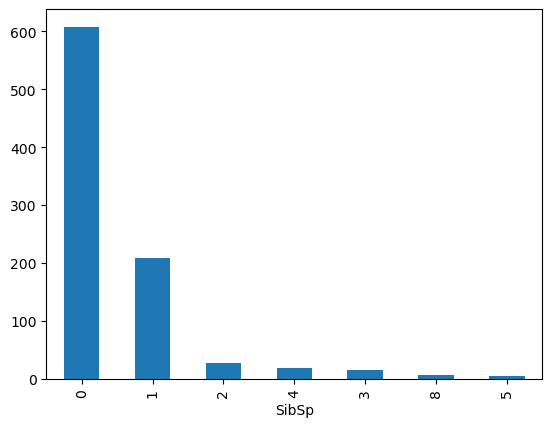

In [60]:
df['SibSp'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

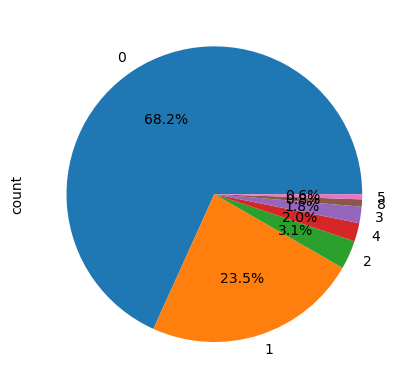

In [63]:
df['SibSp'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [64]:
df['SibSp'].isnull().sum()

0

### Embarked[Univariated Analysis]

***Conclusion***

In [ ]:
df['Embarked'].value_counts()   ### embark means which station passengers boarded S(Southhampton), Q(Queenstown), C(Cherbourgh)

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: xlabel='Embarked'>

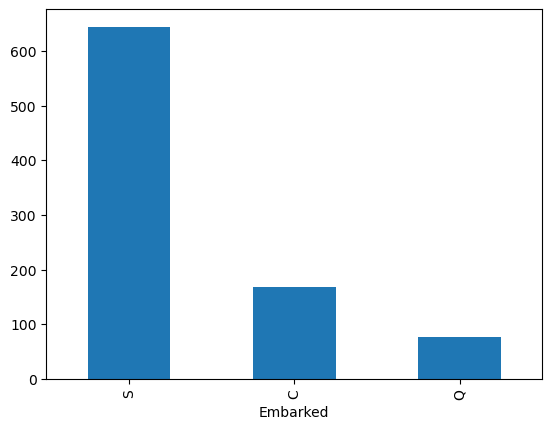

In [66]:
df['Embarked'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

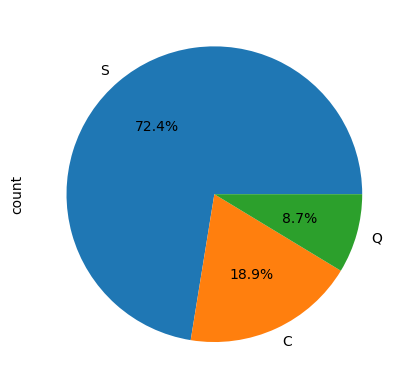

In [67]:
df['Embarked'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [68]:
df['Embarked'].isnull().sum()

2

### Sex[Univariated Analysis]

***Conclusion***

In [69]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex'>

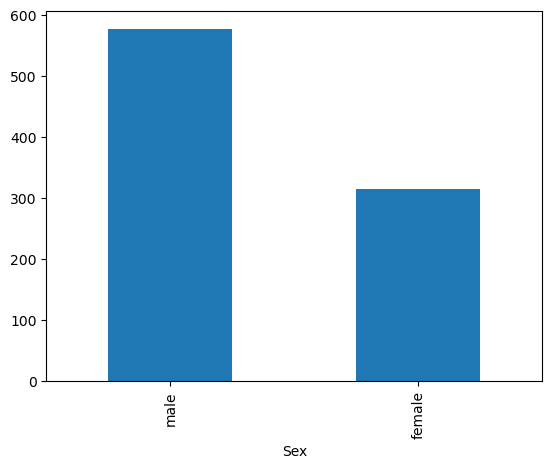

In [70]:
df['Sex'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

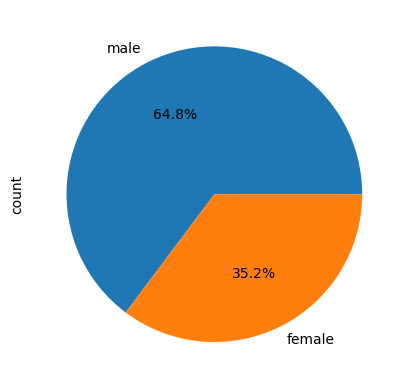

In [71]:
df['Sex'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [73]:
df['Sex'].isnull().sum()

0

### Parch[Univariated Analysis]

***Conclusion***

In [ ]:
df['Parch'].value_counts()  ### parentchild 

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

<Axes: xlabel='Parch'>

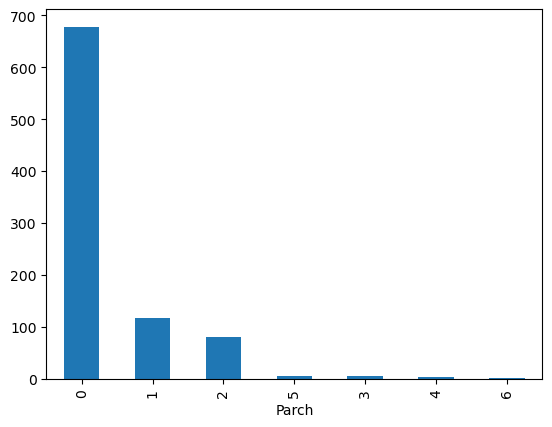

In [75]:
df['Parch'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

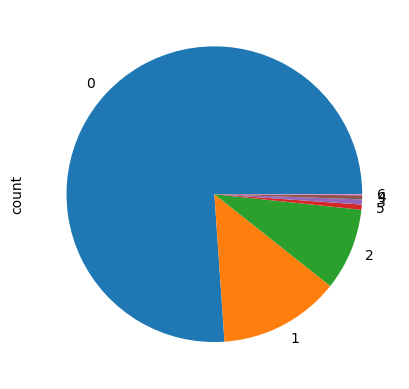

In [77]:
df['Parch'].value_counts().plot(kind='pie' )

In [78]:
df['Parch'].isnull().sum()

0

### Bivariated Analysis

- select 2 col
- understand type of relationship:
  1. Num-Num
  2. Num-Catg
  3. Catg-Catg

***Note:***
- step 1: find the most important col of dataset acc to ps(survived and age)
- step 2: compare imp col to all col

### Survived[Bivariated Analysis]

***Conclusion***

- Most female Survived
- Most 1 pclass survived then 2 Pclass 
- Most Cherbourg passengers survived(Mostly 1 Pclass)

In [ ]:
pd.crosstab(df['Survived'],df['Pclass'], normalize='columns')*100   ## by normalize attribute we are getting percentage in the form 0.37 , which when *100 =37% 
                                                                    ## when normalize in index we get out of survived how many 1 pclass etc
                                                                    ## when normalize in columns we get out of 1 pclass how many survived

Pclass,1,2,3
Survived,,,
0,37.037037,52.717391,75.763747
1,62.962963,47.282609,24.236253


<Axes: xlabel='Pclass', ylabel='Survived'>

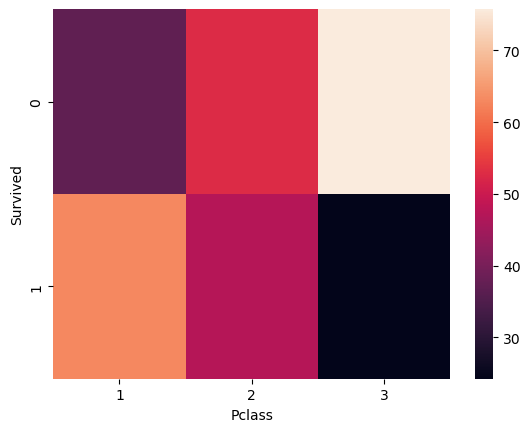

In [10]:
sns.heatmap(pd.crosstab(df['Survived'],df['Pclass'], normalize='columns')*100)

In [11]:
pd.crosstab(df['Survived'],df['Sex'], normalize='columns')*100

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


<Axes: xlabel='Sex', ylabel='Survived'>

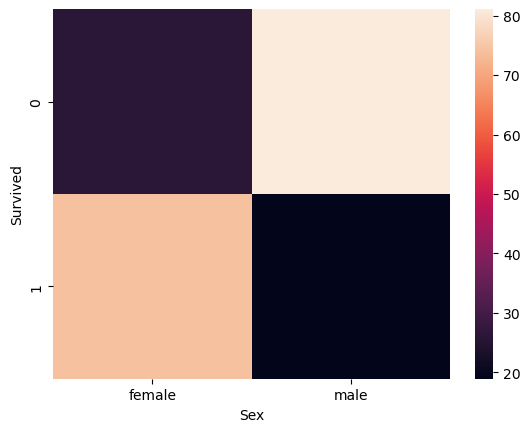

In [12]:
sns.heatmap(pd.crosstab(df['Survived'],df['Sex'], normalize='columns')*100)

In [15]:
pd.crosstab(df['Survived'],df['Embarked'], normalize='columns')*100

Embarked,C,Q,S
Survived,,,
0,44.642857,61.038961,66.304348
1,55.357143,38.961039,33.695652


<Axes: xlabel='Embarked', ylabel='Survived'>

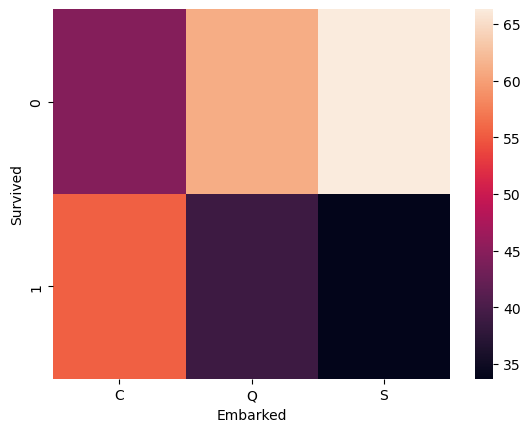

In [16]:
sns.heatmap(pd.crosstab(df['Survived'],df['Embarked'], normalize='columns')*100)

***Embarked[Bivariated Analysis w Sex & Pclass]***

- surprisingly most cherbourg passengers Survived
- since Many of Cherbourg passengers were 1 Pclass 

In [17]:
pd.crosstab(df['Sex'],df['Embarked'], normalize='columns')*100

Embarked,C,Q,S
Sex,,,
female,43.452381,46.753247,31.521739
male,56.547619,53.246753,68.478261


In [18]:
pd.crosstab(df['Pclass'],df['Embarked'], normalize='columns')*100

Embarked,C,Q,S
Pclass,,,
1,50.595238,2.597403,19.720497
2,10.119048,3.896104,25.465839
3,39.285714,93.506494,54.813665


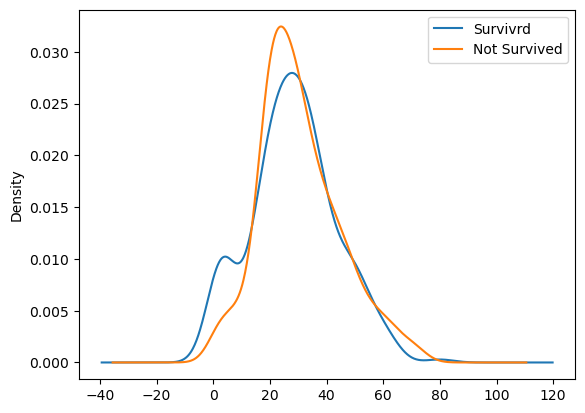

In [ ]:
df[df['Survived'] == 1]['Age'].plot(kind='kde', label='Survivrd')   ### df['Survived'] == 1 this part acts like a true or false, a filter of the column , who survived
                                                                    ### df[df['Survived'] == 1]  now with the filter inside , the dataframe displays rows where it is true
                                                                    ### df[df['Survived'] == 1]['Age']  now it means of the rows that survived, display its age 
df[df['Survived'] == 0]['Age'].plot(kind='kde', label='Not Survived')

plt.legend()           ## without this the scale does not appear on top right corner
plt.show()

***Why slight survival rate increase from 35 to 40?[slight right tilt]***
- since 0-10 year old get priority , survival graph inc
- 10 - 40 are the responsible ones and left on own, survival graph dec
- Surprising tilt may be due to 1 pclass 
- yes thats the reason, avg age of 1 Pclass is 38 
- also female mostly survived , but not that contibution coz avg 27 and mostly in 2 & 3 class [2 & 3 class most not survived]
- also earlier noticed that Cherbourg mostly survived, mostly 1 Pclass,  but most men, most avg 38 
- we can say most survival , most men, avg 38 age all points to characteristics of 1 Pclass


In [6]:
df[df['Pclass'] == 1]['Age'].mean()

38.233440860215055

In [18]:
df[df['Pclass'] == 2]['Age'].mean()

29.87763005780347

In [19]:
df[df['Pclass'] == 3]['Age'].mean()

25.14061971830986

In [7]:
df[df['Sex'] == 'female']['Age'].mean()

27.915708812260537

In [10]:
df[df['Sex'] == 'female']['Pclass'].mean()

2.159235668789809

In [16]:
df[df['Embarked'] == 'C']['Age'].mean()

30.81476923076923

In [17]:
pd.crosstab(df['Sex'],df['Pclass'], normalize='columns')*100

Pclass,1,2,3
Sex,,,
female,43.518519,41.304348,29.327902
male,56.481481,58.695652,70.672098


In [21]:
pd.crosstab(df['Sex'],df['Survived'], normalize='columns')*100

Survived,0,1
Sex,,
female,14.754098,68.128655
male,85.245902,31.871345


### Feature Engineering [Fare Column]

In [22]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [23]:
df[df['SibSp']== 8]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


***All the people having 8 family members are actually one family***
- all have same surnames'Sage', all have same fares[noticed this observation earlier]
- 7 have same ticket no too, missing one

In [ ]:
df[df['Ticket'] == 'CA. 2343']   ### got only 7 out of 8

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [26]:
df[df['Name'].str.contains('Sage')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
641,642,1,1,"Sagesser, Mlle. Emma",female,24.0,0,0,PC 17477,69.30,B35,C
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


***In this train Family dataset we are missing Sage family members***

- they have 8 members , but we are finding 7 with same ticket no and title 'Sage'.
- now we gonna find others in test dataset
- so we will concat , that is merge both dataset and find them
- surprisingly after concat or merge, we know Sage family 11 members onboard.
- 9 together counted[8 sib + ownself],another 2 together counted[1 sib + ownself]

In [27]:
df1 = pd.read_csv('titanictest.csv')

In [ ]:
df = pd.concat([df,df1])    ### df now has both df and df1 datasets

In [ ]:
df[df['Ticket'] == 'CA. 2343']   
                            

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0.0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0.0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0.0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0.0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0.0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0.0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0.0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S
188,1080,NaN,3,"Sage, Miss. Ada",female,NaN,8,2,CA. 2343,69.55,NaN,S
342,1234,NaN,3,"Sage, Mr. John George",male,NaN,1,9,CA. 2343,69.55,NaN,S
360,1252,NaN,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,NaN,S


In [30]:
df['Ticket'].value_counts()

Ticket
CA. 2343        11
CA 2144          8
1601             8
PC 17608         7
S.O.C. 14879     7
                ..
113792           1
36209            1
323592           1
315089           1
359309           1
Name: count, Length: 929, dtype: int64

***Goodwin family 8 members, 6 together counted[5+1], 2 together counted[1+1]***

In [ ]:
df[df['Ticket'] == 'CA 2144']   

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
59,60,0.0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9,NaN,S
71,72,0.0,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.9,NaN,S
386,387,0.0,3,"Goodwin, Master. Sidney Leonard",male,1.0,5,2,CA 2144,46.9,NaN,S
480,481,0.0,3,"Goodwin, Master. Harold Victor",male,9.0,5,2,CA 2144,46.9,NaN,S
678,679,0.0,3,"Goodwin, Mrs. Frederick (Augusta Tyler)",female,43.0,1,6,CA 2144,46.9,NaN,S
683,684,0.0,3,"Goodwin, Mr. Charles Edward",male,14.0,5,2,CA 2144,46.9,NaN,S
139,1031,NaN,3,"Goodwin, Mr. Charles Frederick",male,40.0,1,6,CA 2144,46.9,NaN,S
140,1032,NaN,3,"Goodwin, Miss. Jessie Allis",female,10.0,5,2,CA 2144,46.9,NaN,S


In [34]:
df['ind_fare'] = df['Fare']/(df['SibSp'] + df['Parch'] + 1)

In [35]:
df['ind_fare']

0        3.625000
1       35.641650
2        7.925000
3       26.550000
4        8.050000
          ...    
413      8.050000
414    108.900000
415      7.250000
416      8.050000
417      7.452767
Name: ind_fare, Length: 1309, dtype: float64

In [42]:
df[['ind_fare','Fare']].describe()   ### df[['ind_fare','Fare']]  makes appear both col side by side

,ind_fare,Fare
count,1308.000000,1308.000000
mean,20.518215,33.295479
std,35.774337,51.758668
min,0.000000,0.000000
25%,7.452767,7.895800
50%,8.512483,14.454200
75%,24.237500,31.275000
max,512.329200,512.329200


### Feature Engineering[Family type & Family Size]

In [44]:
df['family_size'] = df['SibSp']+ df['Parch'] + 1

In [ ]:
def transform_family_size(num):
    if num == 1:
        return 'alone'
    elif num > 1 and num < 5:
        return 'small family'
    else:
        return 'large family'
    
df['family_type']=df['family_size'].apply(transform_family_size)

### Bivariated Analysis on Featured Engineered Col[family_type]

***family type , Surname , Title [Feature Engineered]***

- analyzed which family type survives
- analyzed which title[mr, mrs,etc] survives
- taking in notice family names so Surname[owens etc]

In [48]:
pd.crosstab(df['Survived'],df['family_type'], normalize='columns')*100

family_type,alone,large family,small family
Survived,,,
0.0,69.646182,83.870968,42.123288
1.0,30.353818,16.129032,57.876712


In [95]:
df['Surname'] = df['Name'].str.split(',').str.get(0)

In [63]:
df['title'] = df['Name'].str.split(',').str.get(1).str.strip().str.split(' ').str.get(0)

In [65]:
df['title'].value_counts()

title
Mr.          757
Miss.        260
Mrs.         197
Master.       61
Rev.           8
Dr.            8
Col.           4
Mlle.          2
Major.         2
Ms.            2
Lady.          1
Sir.           1
Mme.           1
Don.           1
Capt.          1
the            1
Jonkheer.      1
Dona.          1
Name: count, dtype: int64

In [81]:
df['title'] = (
    df['Name']
    .str.extract(r',\s*([^\.]+)\.', expand=False)
    .replace(['Dr', 'Col', 'Major', 'Don', 'Capt', 'the', 'Jonkheer','Rev','Ms','Mlle','Mme','Lady','Sir','the Countess','Dona'], 'other')
    + '.'
)


In [94]:
df = df[df['title'].isin(['Mr.','Miss.','Mrs.','Master.','other.'])]  ### suggested one ,another method :temp_df = df[df['title'].isin(['Mr.','Miss.','Mrs.','Master.','other.'])]

In [83]:
df['title'].value_counts()

title
Mr.        757
Miss.      260
Mrs.       197
Master.     61
other.      34
Name: count, dtype: int64

In [ ]:
pd.crosstab(df['Survived'],df['title'],normalize='columns')*100   ###suggested one : pd.crosstab(temp_df['Survived'],temp_df['title'],normalize='columns')*100
                                                                 

title,Master.,Miss.,Mr.,Mrs.,other.
Survived,,,,,
0.0,42.5,30.21978,84.332689,20.8,55.555556
1.0,57.5,69.78022,15.667311,79.2,44.444444


### Feature Engineered[Deck col]

- Cabin is not directly related to Survived col
- created Deck which is a major factor in Survived people
- biggest Issue missing value , analyzed with tha availed info considering missing cabin names as M deck cabins

In [ ]:
df['Cabin'].isnull().sum()/len(df['Cabin'])*100   ##77% missing values in this col
                                                  ## actually very imp col but not much records
                                                  ## read in wiki about titanic decks like a , g ,here cabins first letter is actually deck , so survival also depends on deck
                                                  ## deck closely related to ship layout so very imp

77.46371275783041

In [ ]:
### df['Cabin'].fillna('M')  this line doenot work although correct , panda issue, like x = missing value 1 = new value, so pd x + 1 dont understnd but, x = x + 1 understnd
df['Cabin']=df['Cabin'].fillna('M')   ## missing Cabin values filed as M Cabin 

In [107]:
df['deck'] = df['Cabin'].str[0]   ## new col showing deck from cabin col, that is its first letter

In [ ]:
pd.crosstab(df['deck'],df['Pclass'])

Pclass,1,2,3
deck,,,
A,22,0,0
B,65,0,0
C,94,0,0
D,40,6,0
E,34,4,3
F,0,13,8
G,0,0,5
M,67,254,693
T,1,0,0


In [113]:
pd.crosstab(df['deck'],df['Survived'],normalize='index')*100

Survived,0.0,1.0
deck,,
A,53.333333,46.666667
B,25.531915,74.468085
C,40.677966,59.322034
D,24.242424,75.757576
E,25.000000,75.000000
F,38.461538,61.538462
G,50.000000,50.000000
M,70.014556,29.985444
T,100.000000,0.000000


<Axes: xlabel='deck'>

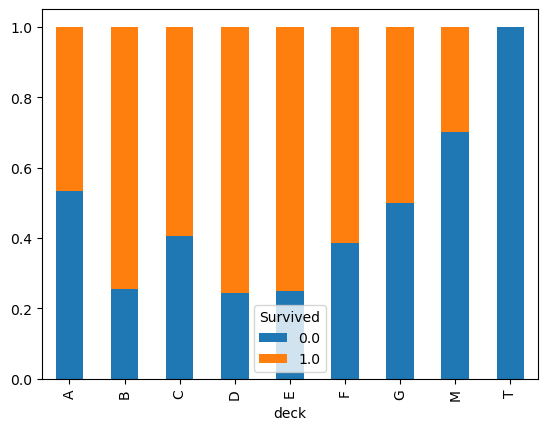

In [ ]:
pd.crosstab(df['deck'],df['Survived'],normalize='index').plot(kind='bar',stacked=True)  ### analyzed survival chance with decks[feature engd]
                                                                                        ###ticket col left to figure out what to do , didnt find that relevant